In [18]:
import logging
import os
import sys
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
from typing import List, Tuple, Optional
import gc
from pathlib import Path

import resource
HAS_RESOURCE = True

current_file_path = Path.cwd() 
project_root_path = current_file_path.parent 
project_root_str = str(project_root_path)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

from src.utils.utils import *

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

### Utils

In [2]:
def get_memory_usage_gb() -> float:
    """Gets current peak memory."""
    if not HAS_RESOURCE:
        return -1.0 
    # ru_maxrss is typically in KB, convert to GB
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / (1024.0 * 1024.0)

def compute_core_features(df):
    # Midprice
    df["mid_price"] = (df["L1_bid_price"] + df["L1_ask_price"]) / 2
    # Spread
    df["spread"] = df["L1_ask_price"] - df["L1_bid_price"]

    # Weighted MidPrice (WMP)
    df["weighted_mid_price"] = (df["L1_bid_price"] * df["L1_ask_size"] + df["L1_ask_price"] * df["L1_bid_size"]) / (
        df["L1_bid_size"] + df["L1_ask_size"]
    )
    # Order Book Imbalance (OBI) - niveau 1
    df["obi_L1"] = (df["L1_bid_size"] - df["L1_ask_size"]) / (df["L1_bid_size"] + df["L1_ask_size"])
    
    # Depth imbalance (L1 à L10)
    bid_cols = [f"L{i}_bid_size" for i in range(1, 11)]
    ask_cols = [f"L{i}_ask_size" for i in range(1, 11)]
    df["cum_bid_vol_10"] = df[bid_cols].sum(axis=1)
    df["cum_ask_vol_10"] = df[ask_cols].sum(axis=1)
    df["depth_imbalance_10"] = (df["cum_bid_vol_10"] - df["cum_ask_vol_10"]) / (
        df["cum_bid_vol_10"] + df["cum_ask_vol_10"]
    )
    # Liquidity metrics
    df["liquidity_impact_bid"] = df["L1_bid_price"] - df["L2_bid_price"]
    df["liquidity_impact_ask"] = df["L2_ask_price"] - df["L1_ask_price"]
    return df

In [10]:
BASE_DATA_PATH = '/mnt/storage_1_10T/citibank/egbs_data_02_25'

DAYS_TO_PROCESS = [
    '20250212', '20250213', '20250214', '20250217', '20250218',
    '20250219', '20250220', '20250221', '20250224', '20250225'
]

SYMBOLS_TO_EXCLUDE = ['FGBLM5', 'CONFH5']
NB_BARS_PER_DAY_SYMBOL = 10000
WINDOW_LENGTH = 150
TARGET_WINDOW_LENGTH = 30
TARGET_COLUMN_NAME = 'wmp_mean'
BASE_OUTPUT_DIR = '/mnt/storage_1_10T/Citibank/processed_data_volume_bars'
PARAMS_SUBDIR = f"volbars_{NB_BARS_PER_DAY_SYMBOL}_in{WINDOW_LENGTH}_tgt{TARGET_WINDOW_LENGTH}_TEST"
OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, PARAMS_SUBDIR)

os.makedirs(OUTPUT_DIR, exist_ok=True)
logging.info(f"Output directory: {OUTPUT_DIR}")

2025-05-16 19:42:38 - INFO - Output directory: /mnt/storage_1_10T/Citibank/processed_data_volume_bars/volbars_10000_in150_tgt30_TEST


In [4]:
OUTPUT_DIR

'/mnt/storage_1_10T/Citibank/processed_data_volume_bars/volbars_10000_in150_tgt30_TEST'

### Data Loading

In [5]:
day = '20250212'

logging.info(f"--- Processing Day: {day} ---")
day_start_time = time.time()
day_peak_mem_start = get_memory_usage_gb()
day_peak_mem_current = day_peak_mem_start

step_start_time = time.time()
logging.info(f"Step 1: Loading raw data for {day}...")
df_day_raw = load_and_clean_day_data(BASE_DATA_PATH, day)
load_time = time.time() - step_start_time
mem_after_load = get_memory_usage_gb()
day_peak_mem_current = max(day_peak_mem_current, mem_after_load)
logging.info(f"Step 1 (Load) complete: Time={load_time:.2f}s, Peak Mem={mem_after_load:.2f} GB, Shape={df_day_raw.shape if df_day_raw is not None else 'None'}")

2025-05-16 19:41:22 - INFO - --- Processing Day: 20250212 ---
2025-05-16 19:41:22 - INFO - Step 1: Loading raw data for 20250212...


--- Loading 20250212 ---


2025-05-16 19:41:42 - INFO - Step 1 (Load) complete: Time=20.22s, Peak Mem=19.13 GB, Shape=(17000000, 72)


Loaded 17,000,000 rows for 20250212 in 20.10s


### Data Cleaning

In [6]:
step_start_time = time.time()
logging.info("Step 2: Cleaning data...")

initial_rows = len(df_day_raw)
df_day_raw.dropna(inplace=True)
df_clean = df_day_raw.copy()
rows_dropped = initial_rows - len(df_clean)

percent_dropped = (rows_dropped / initial_rows * 100) if initial_rows > 0 else 0.0

logging.info(f"Dropped {rows_dropped:,} rows with NaNs ({percent_dropped:.2f}%). Shape after NaN drop: {df_clean.shape}")
columns_to_drop = [
    'exch_time', 'exchange', 'first_sequence_number', 'last_sequence_number',
    'first_sym_sequence', 'last_sym_sequence', 'first_time', 'first_exch_time',
    'event_id', 'date'
]

existing_cols_to_drop = [col for col in columns_to_drop if col in df_clean.columns]

if existing_cols_to_drop:
    df_clean.drop(columns=existing_cols_to_drop, inplace=True)
    logging.info(f"Dropped unused columns: {existing_cols_to_drop}. Shape now: {df_clean.shape}")

clean_time = time.time() - step_start_time
mem_after_clean = get_memory_usage_gb()
day_peak_mem_current = max(day_peak_mem_current, mem_after_clean)
logging.info(f"Step 2 (Clean) complete: Time={clean_time:.2f}s, Peak Mem={mem_after_clean:.2f} GB")

del df_day_raw; gc.collect()

2025-05-16 19:41:42 - INFO - Step 2: Cleaning data...
2025-05-16 19:41:56 - INFO - Dropped 5,265 rows with NaNs (0.03%). Shape after NaN drop: (16994735, 72)
2025-05-16 19:41:58 - INFO - Dropped unused columns: ['exch_time', 'exchange', 'first_sequence_number', 'last_sequence_number', 'first_sym_sequence', 'last_sym_sequence', 'first_time', 'first_exch_time', 'event_id', 'date']. Shape now: (16994735, 62)
2025-05-16 19:41:58 - INFO - Step 2 (Clean) complete: Time=16.20s, Peak Mem=34.05 GB


10

### Features Computation

In [7]:
step_start_time = time.time()
logging.info("Step 3: Computing core features...")
df_featured = compute_core_features(df_clean)
feature_time = time.time() - step_start_time
mem_after_features = get_memory_usage_gb()
day_peak_mem_current = max(day_peak_mem_current, mem_after_features)
logging.info(f"Step 3 (Features) complete: Time={feature_time:.2f}s, Peak Mem={mem_after_features:.2f} GB, Shape={df_featured.shape}")
del df_clean; gc.collect()

2025-05-16 19:41:58 - INFO - Step 3: Computing core features...
2025-05-16 19:42:02 - INFO - Step 3 (Features) complete: Time=4.28s, Peak Mem=34.05 GB, Shape=(16994735, 71)


0

In [8]:
df_featured.shape

(16994735, 71)

### Symbols Filtering

In [11]:
step_start_time = time.time()
logging.info(f"Step 4: Filtering symbols (excluding {SYMBOLS_TO_EXCLUDE})...")
initial_syms = df_featured['sym'].nunique()
df_filtered = df_featured[~df_featured['sym'].isin(SYMBOLS_TO_EXCLUDE)].copy()
syms_dropped = initial_syms - df_filtered['sym'].nunique()
filter_time = time.time() - step_start_time
mem_after_filter = get_memory_usage_gb()
day_peak_mem_current = max(day_peak_mem_current, mem_after_filter)
logging.info(f"Step 4 (Filter Sym) complete: Time={filter_time:.2f}s, Peak Mem={mem_after_filter:.2f} GB")
logging.info(f"Dropped {syms_dropped} symbols. Shape after symbol filter: {df_filtered.shape}")
del df_featured; gc.collect()

2025-05-16 19:42:43 - INFO - Step 4: Filtering symbols (excluding ['FGBLM5', 'CONFH5'])...
2025-05-16 19:42:55 - INFO - Step 4 (Filter Sym) complete: Time=11.90s, Peak Mem=44.93 GB
2025-05-16 19:42:55 - INFO - Dropped 2 symbols. Shape after symbol filter: (16990559, 71)


1984

### Volume Bar Creation

In [14]:
def compute_nb_bars(
    symbol_data: pd.DataFrame, 
    min_avg_snapshots_per_bar: int = 150,
    max_nb_bars: int = 7500
) -> int:
    """Create volume bars for all symbols based on the number of snapshots.

    This function calculates the number of volume bars for each symbol in the
    provided data map, ensuring that the number of bars does not exceed the
    specified maximum and is based on a minimum average number of snapshots per bar.

    Args:
        symbols_data_map (Dict[str, pd.DataFrame]): A dictionary mapping symbol names to their corresponding DataFrames.
        min_avg_snapshots_per_bar (int, optional): Minimum average snapshots required per bar. Defaults to 150.
        max_nb_bars (int, optional): Maximum number of bars allowed per symbol. Defaults to 7500.

    Returns:
        Dict[str, int]: A dictionary mapping each symbol to the calculated number of bars.
    """
    nb_snapshots = symbol_data.shape[0]
    nb_bars_for_quality = nb_snapshots // min_avg_snapshots_per_bar
    final_nb_bars = min(nb_bars_for_quality, max_nb_bars)
    return final_nb_bars

def create_volume_bars_with_lob_features(
    df_symbol: pd.DataFrame,    
    nb_bars: int,
    activity_col_name: str = 'L1_total_volume', # Renamed for clarity
    wmp_col_name: str = 'weighted_mid_price',
    time_col_name: str = 'time'
) -> Optional[pd.DataFrame]:
    """
    Create aggregated volume bars for a single symbol based on a target number of bars.

    Aggregates LOB features (mean, sum, min, max, std, median) for each bar.

    Args:
        df_symbol (pd.DataFrame): DataFrame containing LOB data for one symbol, 
                                  sorted by time. Must include time, WMP, and L1 sizes.
        nb_bars (int): Target number of volume bars to create for the given data.
        activity_col_name (str): Name for the calculated L1 volume column.
        wmp_col_name (str): Name of the Weighted Mid-Price column.
        time_col_name (str): Name of the timestamp column.

    Returns:
        Optional[pd.DataFrame]: DataFrame where each row represents one volume bar 
                                with aggregated features, or None if bars cannot be created.
    """
    logging.debug(f"Starting volume bar creation for symbol (shape {df_symbol.shape}) with target {nb_bars} bars.")
    
    # Calculate activity volume (L1 Bid Size + L1 Ask Size)
    if 'L1_bid_size' not in df_symbol.columns or 'L1_ask_size' not in df_symbol.columns:
        logging.error("L1 bid/ask size columns missing. Cannot calculate activity volume.")
        return None
    
    # Compute total volume between bid and ask
    df_symbol[activity_col_name] = df_symbol['L1_bid_size'] + df_symbol['L1_ask_size']
    df_symbol[activity_col_name] = df_symbol[activity_col_name].fillna(0)
    
    # Calculate cumulative activity volume
    df_symbol['cumulative_activity_volume'] = df_symbol[activity_col_name].cumsum()

    required_cols = [time_col_name, wmp_col_name, activity_col_name, 'cumulative_activity_volume']
    if not all(col in df_symbol.columns for col in required_cols):
        logging.error(f"Missing required columns for bar creation: Needs {required_cols}. Found {df_symbol.columns.tolist()}")
        return None
    
    # Ensure data is sorted by time (should be done before calling, but double-check)
    if not df_symbol[time_col_name].is_monotonic_increasing:
         logging.warning("Input data not sorted by time. Sorting now...")
         df_symbol = df_symbol.sort_values(time_col_name).reset_index(drop=True)
    
    data = df_symbol.copy()

    #print(data[[time_col_name, wmp_col_name, activity_col_name, 'cumulative_activity_volume']].head())
    
    # Calculate volume threshold per bar
    total_cumulative_volume = data['cumulative_activity_volume'].max()
    if total_cumulative_volume == 0 or nb_bars == 0:
        logging.warning("Total cumulative volume or number of bars is zero. Cannot create bars.")
        return None
    
    volume_threshold = total_cumulative_volume / nb_bars 
    logging.info(f"Calculated Volume Threshold per bar: {volume_threshold:.2f} (Total Vol: {total_cumulative_volume}, Target Bars: {nb_bars})")

    if volume_threshold <= 0:
         logging.warning(f"Volume threshold is non-positive ({volume_threshold:.2f}). Cannot create bars.")
         return None

    # Assign bar ID based on cumulative volume crossing thresholds
    data['bar_id'] = (data['cumulative_activity_volume'] // volume_threshold).astype(int)

    #print(data[[time_col_name, wmp_col_name, activity_col_name, 'cumulative_activity_volume', 'bar_id']].head())

    # Handle edge case: First few entries might be below the first threshold / Ensure they belong to bar 0
    if data.empty:
        logging.warning("Data is empty before attempting to access first_bar_id. Cannot create bars.")
        return None
    first_bar_id = data.iloc[0]['bar_id'] 
    data.loc[data['bar_id'] == first_bar_id, 'bar_id'] = 0 

    # Exclude snapshots belonging to a potentially partial last bar
    # Ensure we only include bars where the *next* threshold was crossed
    max_possible_bar_id = int(np.floor(total_cumulative_volume / volume_threshold)) -1 
    logging.info(f"max_possible_bar_id: {max_possible_bar_id}")
    if max_possible_bar_id < 0:
        logging.warning("Not enough volume to form even one full bar.")
        return None
        
    data_full_bars = data[data['bar_id'] <= max_possible_bar_id].copy()
    if data_full_bars.empty:
        logging.warning("No full bars could be formed after excluding the partial last bar.")
        return None
        
    logging.debug(f"Data filtered to full bars (Bar IDs 0 to {max_possible_bar_id}). Shape: {data_full_bars.shape}")

    # Identify features to aggregate
    # LOB Level features (L1-L10 price, size, no)
    level_cols = [col for col in data_full_bars.columns if col.startswith('L') and ('_price' in col or '_size' in col or '_no' in col)]
    # Microstructure features (spread, obi, imbalance, etc.)
    lob_features = ['spread', 'obi_L1', 'cum_bid_vol_10','cum_ask_vol_10', 
                    'depth_imbalance_10', 'liquidity_impact_bid',
                    'liquidity_impact_ask']
    # Filter lob_features to only include those present in the dataframe
    lob_features = [f for f in lob_features if f in data_full_bars.columns]
    
    # Combine LOB and microstructure features 
    features_to_aggregate = level_cols + lob_features
    
    # Keep essential info columns
    info_cols_to_keep = [time_col_name, wmp_col_name, activity_col_name]

    # Check if features_to_aggregate is empty
    if not features_to_aggregate:
        logging.warning("No LOB features found to aggregate.")
        return None

    # Aggregation function
    def aggregate_bar(bar_group: pd.DataFrame) -> pd.Series:
        results = {
            'bar_start_time': bar_group[time_col_name].iloc[0],
            'bar_end_time': bar_group[time_col_name].iloc[-1],
            'num_snapshots_in_bar': len(bar_group),
            'actual_volume_in_bar': bar_group[activity_col_name].sum(),
            # WMP aggregations
            'wmp_mean': bar_group[wmp_col_name].mean(),
            'wmp_first': bar_group[wmp_col_name].iloc[0],
            'wmp_last': bar_group[wmp_col_name].iloc[-1],
            'wmp_min': bar_group[wmp_col_name].min(),
            'wmp_max': bar_group[wmp_col_name].max(),
            'wmp_median': bar_group[wmp_col_name].median(),
            'wmp_std': bar_group[wmp_col_name].std(),
        }
        # Aggregate other LOB features
        for col in features_to_aggregate:
            results[f"{col}_mean"] = bar_group[col].mean()
            results[f"{col}_sum"] = bar_group[col].sum()
            results[f"{col}_min"] = bar_group[col].min()
            results[f"{col}_max"] = bar_group[col].max()
            results[f"{col}_std"] = bar_group[col].std()
            results[f"{col}_median"] = bar_group[col].median()
            
        return pd.Series(results)
    
    logging.debug(f"Aggregating {len(data_full_bars['bar_id'].unique())} bars using groupby().apply()...")
    # Group by bar_id and apply the aggregation
    grouped_bars = data_full_bars.groupby('bar_id')
    volume_bars_df = grouped_bars.apply(aggregate_bar)
    logging.debug("Aggregation finished.")

    # Calculate bar duration
    volume_bars_df['bar_duration_seconds'] = (
        volume_bars_df['bar_end_time'] - volume_bars_df['bar_start_time']
    ).dt.total_seconds()

    # Final checks
    volume_bars_df = volume_bars_df.reset_index() 
    # Fill NaNs that might result from std() on single-snapshot bars or empty groups
    volume_bars_df.fillna(0, inplace=True) 
    
    logging.info(f"Successfully created {len(volume_bars_df)} volume bars.")
    return volume_bars_df

In [15]:
grouped_symbols = df_filtered.groupby('sym')
num_symbols = len(grouped_symbols)
NB_BARS = 10000
vol_bars_symbols = {}

for sym_name, group_df in tqdm(grouped_symbols, total=num_symbols, desc=f"Sequential Processing {day}"):
    logging.info(f"--- Processing symbol: {sym_name} ---")
    # Calculate nb_bars for this specific symbol
    nb_bars_for_sym = compute_nb_bars(group_df.copy(), max_nb_bars=NB_BARS) # Use main nb_bars as max_nb_bars for consistency
    vol_bars = create_volume_bars_with_lob_features(group_df.copy(), nb_bars=nb_bars_for_sym)
    vol_bars_symbols[sym_name] = vol_bars

Sequential Processing 20250212:   0%|          | 0/8 [00:00<?, ?it/s]2025-05-16 19:43:03 - INFO - --- Processing symbol: FBONH5 ---
2025-05-16 19:43:03 - INFO - Calculated Volume Threshold per bar: 553.58 (Total Vol: 158325.0, Target Bars: 286)
2025-05-16 19:43:03 - INFO - max_possible_bar_id: 285
/tmp/ipykernel_3301599/2242364813.py:168: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  volume_bars_df = grouped_bars.apply(aggregate_bar)
2025-05-16 19:43:05 - INFO - Successfully created 286 volume bars.
Sequential Processing 20250212:  12%|█▎        | 1/8 [00:08<01:02,  8.95s/it]2025-05-16 19:43:05 - INFO - --- Processing symbol: FBTPH5 ---
2025-05-16 19:43:06 - WARNING - Input data not sorted by tim

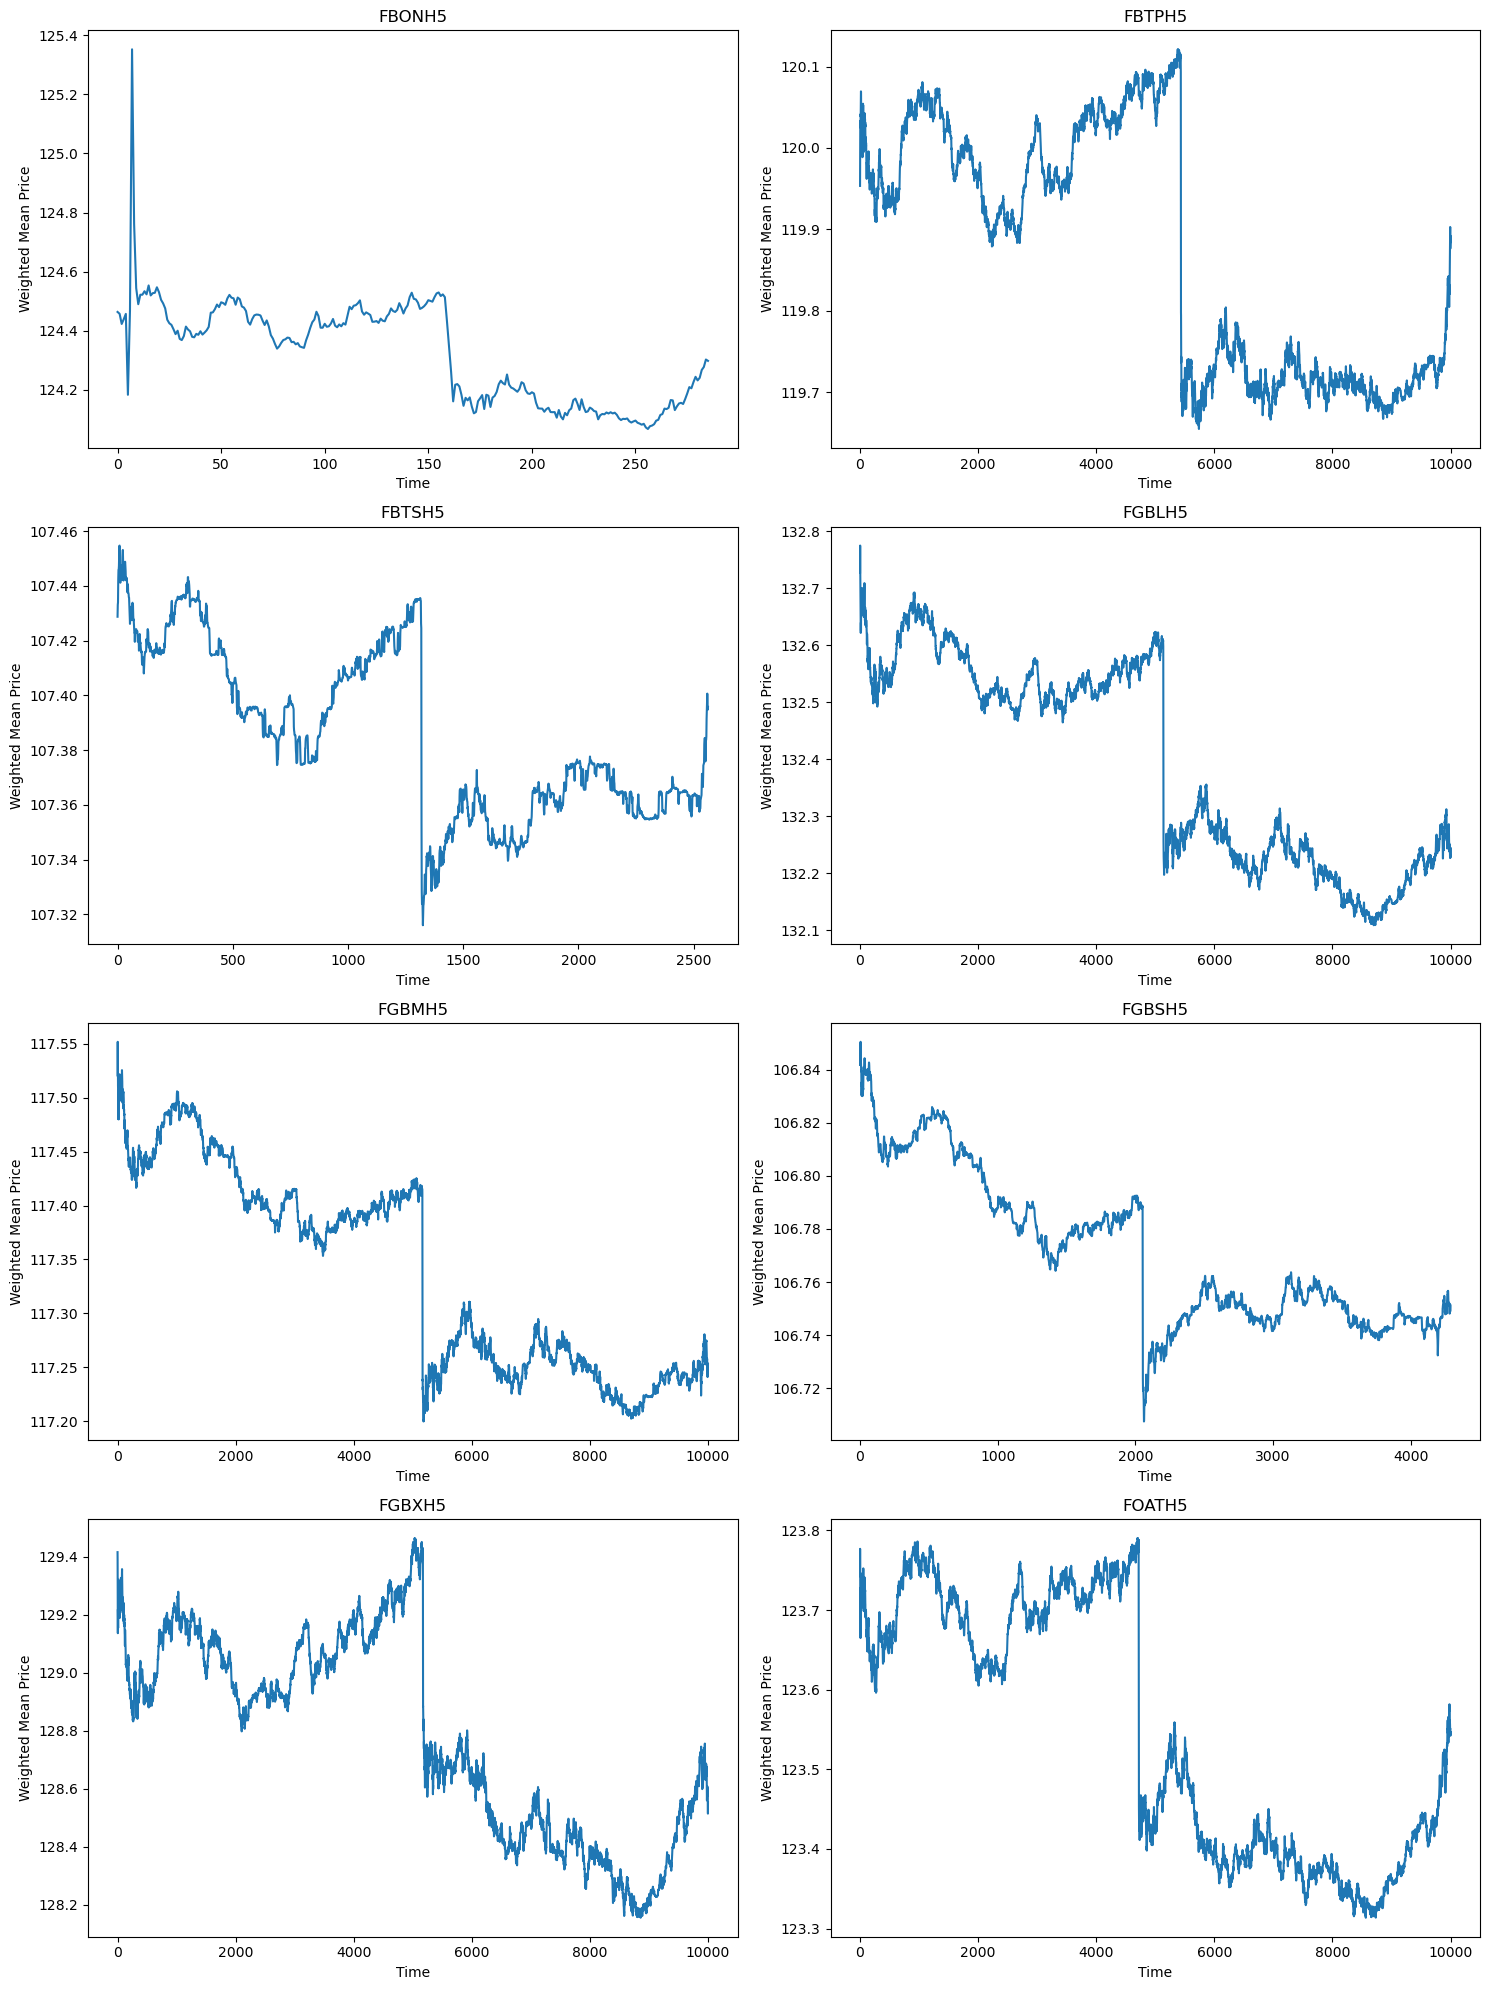

In [20]:
num_symbols = len(vol_bars_symbols)
num_rows = (num_symbols + 1) // 2  # Two plots per row

fig, axes = plt.subplots(num_rows, 2, figsize=(15, 5 * num_rows))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten the axes array for easy indexing

for i, (sym, vol_bars) in enumerate(vol_bars_symbols.items()):
    axes[i].plot(vol_bars['wmp_mean'])
    axes[i].set_title(sym)
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Weighted Mean Price')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [21]:
sym_bar = vol_bars_symbols['FOATH5']

In [22]:
sym_bar

,bar_id,bar_start_time,bar_end_time,num_snapshots_in_bar,actual_volume_in_bar,wmp_mean,wmp_first,wmp_last,wmp_min,wmp_max,...,liquidity_impact_bid_max,liquidity_impact_bid_std,liquidity_impact_bid_median,liquidity_impact_ask_mean,liquidity_impact_ask_sum,liquidity_impact_ask_min,liquidity_impact_ask_max,liquidity_impact_ask_std,liquidity_impact_ask_median,bar_duration_seconds
0,0,2025-02-12 00:15:01.084543637,2025-02-12 00:39:33.195868432,1801,106787.0,123.742623,123.764000,123.764174,123.710227,123.770526,...,0.02,2.356368e-04,0.01,0.01,18.01,0.01,0.01,6.411926e-15,0.01,1472.111325
1,1,2025-02-12 00:39:33.344796277,2025-02-12 02:04:14.721097752,2431,106987.0,123.776791,123.764174,123.744167,123.738182,123.806207,...,0.01,6.776129e-15,0.01,0.01,24.31,0.01,0.01,6.574713e-15,0.01,5081.376301
2,2,2025-02-12 02:04:14.723255522,2025-02-12 03:31:40.136179469,2701,106846.0,123.737456,123.744815,123.719872,123.697470,123.759545,...,0.01,7.039383e-15,0.01,0.01,27.01,0.01,0.01,7.001552e-15,0.01,5245.412924
3,3,2025-02-12 03:31:40.136201418,2025-02-12 04:59:13.307641632,2448,106964.0,123.685399,123.719872,123.698148,123.650263,123.727111,...,0.01,6.154738e-15,0.01,0.01,24.48,0.01,0.01,6.512548e-15,0.01,5253.171440
4,4,2025-02-12 04:59:13.308819547,2025-02-12 06:42:12.319527857,2503,106888.0,123.688620,123.698148,123.668125,123.663333,123.709500,...,0.01,7.106229e-15,0.01,0.01,25.03,0.01,0.01,6.782973e-15,0.01,6179.010708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,2025-02-12 19:52:30.272402271,2025-02-12 19:55:26.259514838,610,106858.0,123.543220,123.553034,123.538963,123.535775,123.553034,...,0.01,3.479341e-15,0.01,0.01,6.10,0.01,0.01,7.066936e-15,0.01,175.987113
9996,9996,2025-02-12 19:55:26.259534209,2025-02-12 19:56:43.582738846,506,106889.0,123.548211,123.538462,123.555080,123.537296,123.555080,...,0.01,5.961239e-15,0.01,0.01,5.06,0.01,0.01,6.988653e-15,0.01,77.323205
9997,9997,2025-02-12 19:56:43.600876435,2025-02-12 19:59:48.168082535,638,106947.0,123.547173,123.555080,123.544231,123.537169,123.558525,...,0.01,6.263884e-15,0.01,0.01,6.38,0.01,0.01,6.683003e-15,0.01,184.567206
9998,9998,2025-02-12 19:59:48.168285027,2025-02-12 20:02:47.253757625,713,106985.0,123.542132,123.543836,123.536994,123.536810,123.546265,...,0.01,0.000000e+00,0.01,0.01,7.13,0.01,0.01,6.491253e-15,0.01,179.085473


### Sliding Windows

In [49]:
def generate_sequential_windows(
    df_bars: pd.DataFrame,
    window_length: int = 100,
    target_window_length: int = 10,
    target_col: str = 'wmp_mean' # Column to use for target prediction
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray], Optional[pd.DataFrame], Optional[List[str]]]:
    """
    Generates sequential, sliding windows and corresponding target windows from aggregated bar data.

    Args:
        df_bars (pd.DataFrame): DataFrame where each row is an aggregated bar (time or volume).
                                Must contain 'bar_end_time' and the target_col ('wmp_mean').
        window_length (int): Number of bars in the input window.
        target_window_length (int): Number of bars in the target window.
        target_col (str): The column within df_bars to use for generating the target window values 
                          (e.g., 'wmp_mean', 'wmp_last').

    Returns:
        Tuple[Optional[np.ndarray], Optional[np.ndarray], Optional[pd.DataFrame], Optional[List[str]]]: 
            - X_windows: NumPy array of input windows (samples, window_length, num_features).
            - target_windows: NumPy array of target values (samples, target_window_length).
            - window_info: DataFrame with metadata for each window (end time, last target value).
            - feature_cols: List of feature names corresponding to the last dimension of X_windows.
            Returns (None, None, None, None) if no windows can be generated.
    """
    logging.info(f"Generating input windows (len={window_length}) and target windows (len={target_window_length}) using target '{target_col}'...")

    required_cols = ['bar_end_time', target_col]
    if not all(col in df_bars.columns for col in required_cols):
        logging.error(f"Input DataFrame for windowing must contain columns: {required_cols}. Found {df_bars.columns.tolist()}")
        return None, None, None, None
        
    # Identify feature columns 
    exclude_cols = ['bar_id', 'bar_start_time', 'bar_end_time', 'num_snapshots_in_bar', 'actual_volume_in_bar', 'bar_duration_seconds']
    feature_cols = [col for col in df_bars.columns if col not in exclude_cols]
    
    if not feature_cols:
        logging.error("No feature columns identified for windowing.")
        return None, None, None, None

    num_features = len(feature_cols)
    logging.info(f"Using {num_features} input features for windows.") 

    # Ensure features are numeric and handle NaNs
    logging.debug("Converting features to float32 and checking for NaNs...")
    try:
        feature_data = df_bars[feature_cols].fillna(0).astype(np.float32).values
        if np.isnan(feature_data).any() or np.isinf(feature_data).any():
             logging.warning("NaN or Inf values found in feature data after fillna(0). Check data pipeline.")
             # Optionally, apply more robust NaN handling like imputation if needed
             feature_data = np.nan_to_num(feature_data, nan=0.0, posinf=0.0, neginf=0.0) 
    except Exception as e:
        logging.error(f"Error converting features to float32: {e}", exc_info=True)
        return None, None, None, None
    logging.debug("Feature conversion and NaN check complete.")

    # Extract time and target columns
    times = df_bars['bar_end_time'].values
    targets = df_bars[target_col].astype(np.float32).values # Target values

    # Check if enough data exists for at least one window
    total_bars = len(df_bars)
    required_bars = window_length + target_window_length
    if total_bars < required_bars:
        logging.warning(f"Not enough bars ({total_bars}) to create a window of length {window_length} + target {target_window_length}.")
        return None, None, None, None

    X_windows_list, target_windows_list, window_info_list = [], [], []
    
    logging.debug(f"Iterating to create windows (Total bars: {total_bars}, Required per window: {required_bars})...")

    # Iterate through the bars to create sliding windows
    for i in range(total_bars - required_bars + 1):
        input_end_idx = i + window_length
        target_start_idx = input_end_idx
        target_end_idx = target_start_idx + target_window_length

        # Slice input features
        input_window_slice = feature_data[i : input_end_idx]
        
        # Slice target variable for the future window
        target_window_slice = targets[target_start_idx : target_end_idx]
        
        X_windows_list.append(input_window_slice)
        target_windows_list.append(target_window_slice)

        assert input_window_slice[-1,0] == targets[target_start_idx-1]
        assert input_window_slice[-1,0] == targets[input_end_idx - 1]

        # Store metadata: time corresponds to the *end* of the input window
        info = {
            'window_end_time': times[input_end_idx - 1], 
            'last_target_in_window': targets[input_end_idx - 1] # Store last target value of the input window
        }
        
        # Store the last target value of the input window
        window_info_list.append(info)

    logging.debug(f"Finished iterating. Created {len(X_windows_list)} raw windows.")

    if not X_windows_list:
        logging.warning("No windows were generated after iteration.")
        # Return empty structures with correct shapes/columns
        empty_x = np.array([]).reshape(0, window_length, num_features).astype(np.float32)
        empty_tgt = np.array([]).reshape(0, target_window_length).astype(np.float32)
        empty_info = pd.DataFrame(columns=['window_end_time', 'last_target_in_window'])
        return empty_x, empty_tgt, empty_info, feature_cols

    # Stack lists into final NumPy arrays and DataFrame
    logging.debug("Stacking window lists into final arrays...")
    try:
        X_windows = np.stack(X_windows_list, axis=0).astype(np.float32)
        target_windows = np.stack(target_windows_list, axis=0).astype(np.float32)
        window_info = pd.DataFrame(window_info_list)
        # Ensure time column is datetime
        window_info['window_end_time'] = pd.to_datetime(window_info['window_end_time']) 
        # Sort by time just in case (though generation is sequential)
        window_info = window_info.sort_values('window_end_time').reset_index(drop=True) 
        # Reorder X and target arrays based on sorted info
        # This is crucial if parallel processing were used, but good practice anyway
        # Assuming sequential generation, indices should already match sort order
        # X_windows = X_windows[window_info.index] 
        # target_windows = target_windows[window_info.index]
        
    except Exception as e:
         logging.error(f"Error stacking final window arrays: {e}", exc_info=True)
         return None, None, None, None
    logging.debug("Stacking complete.")

    logging.info(f"Window generation complete.")
    logging.info(f"Shape of X_windows: {X_windows.shape}")
    logging.info(f"Shape of target_windows: {target_windows.shape}")
    logging.info(f"Shape of window_info: {window_info.shape}")
    logging.info(f"Data type of X_windows: {X_windows.dtype}")
    logging.info(f"Data type of target_windows: {target_windows.dtype}")

    return X_windows, target_windows, window_info, feature_cols

In [50]:
X_windows, target_windows, window_info, feature_cols = generate_sequential_windows(
    df_bars=vol_bars_symbols['FOATH5'],
    window_length=100,
    target_window_length=10,
    target_col='wmp_mean'
)

2025-05-16 20:13:18 - INFO - Generating input windows (len=100) and target windows (len=10) using target 'wmp_mean'...
2025-05-16 20:13:18 - INFO - Using 409 input features for windows.
2025-05-16 20:13:20 - INFO - Window generation complete.
2025-05-16 20:13:20 - INFO - Shape of X_windows: (9891, 100, 409)
2025-05-16 20:13:20 - INFO - Shape of target_windows: (9891, 10)
2025-05-16 20:13:20 - INFO - Shape of window_info: (9891, 2)
2025-05-16 20:13:20 - INFO - Data type of X_windows: float32
2025-05-16 20:13:20 - INFO - Data type of target_windows: float32


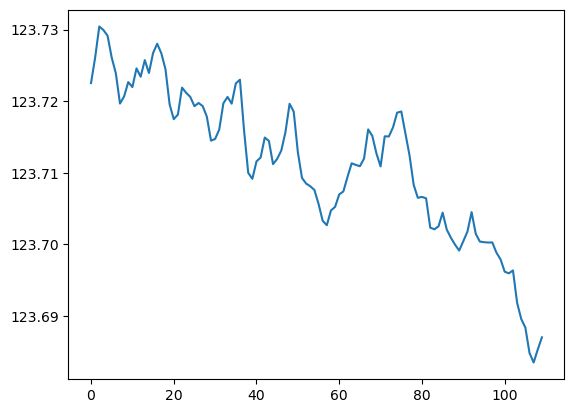

In [66]:
idx = 1580

plt.plot(np.concatenate((X_windows[idx,:,0], target_windows[idx])))

#plt.plot(X_windows[idx,:,0])

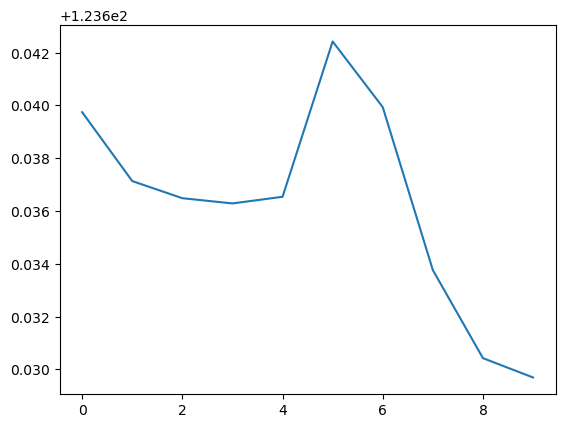

In [54]:
plt.plot(target_windows[idx])

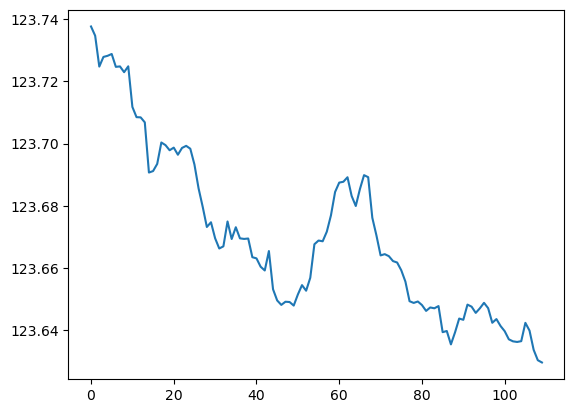

In [64]:
plt.plot(np.concatenate((X_windows[idx,:,0], target_windows[idx])))